In [1]:
%load_ext autoreload
%autoreload 2

import pennylane as qml
import jax
import jax.numpy as jnp
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

jax.devices()

E0412 20:33:39.814447  149852 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0412 20:33:39.854043  149786 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


[CudaDevice(id=0)]

torch.Size([32, 1, 28, 28])
torch.Size([28, 28])
tensor(0.) tensor(0.9961)
Nombre de patches: 49


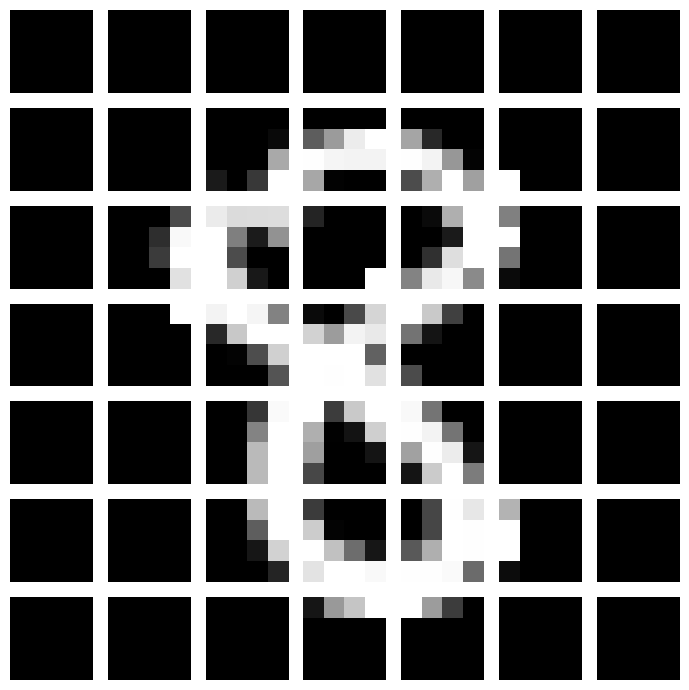

In [2]:
from data.dataloader import dataloader

batch_size = 32
train_ld, test_ld = dataloader('MNIST', batch_size, True)

for t in train_ld:
    batch_image, label = t
    break

print(batch_image.shape)  # [batch_size, 1, 28, 28]
# Supprimer la dimension du canal
image = batch_image[0].squeeze(0)  # [batch_size, 28, 28]
print(image.shape)  # [28, 28]
print(image.min(), image.max())  # [0, 1]

# Découper en patches 4x4
patch_size = 4
patches = []

for i in range(0, 28, patch_size):
    for j in range(0, 28, patch_size):
        patch = image[i:i+patch_size, j:j+patch_size]
        patches.append(patch)

patches = torch.stack(patches)  # [49, 4, 4]

print("Nombre de patches:", patches.shape[0])

# Affichage des patches
fig, axes = plt.subplots(7, 7, figsize=(7, 7))

for idx, ax in enumerate(axes.flatten()):
    ax.imshow(patches[idx], cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

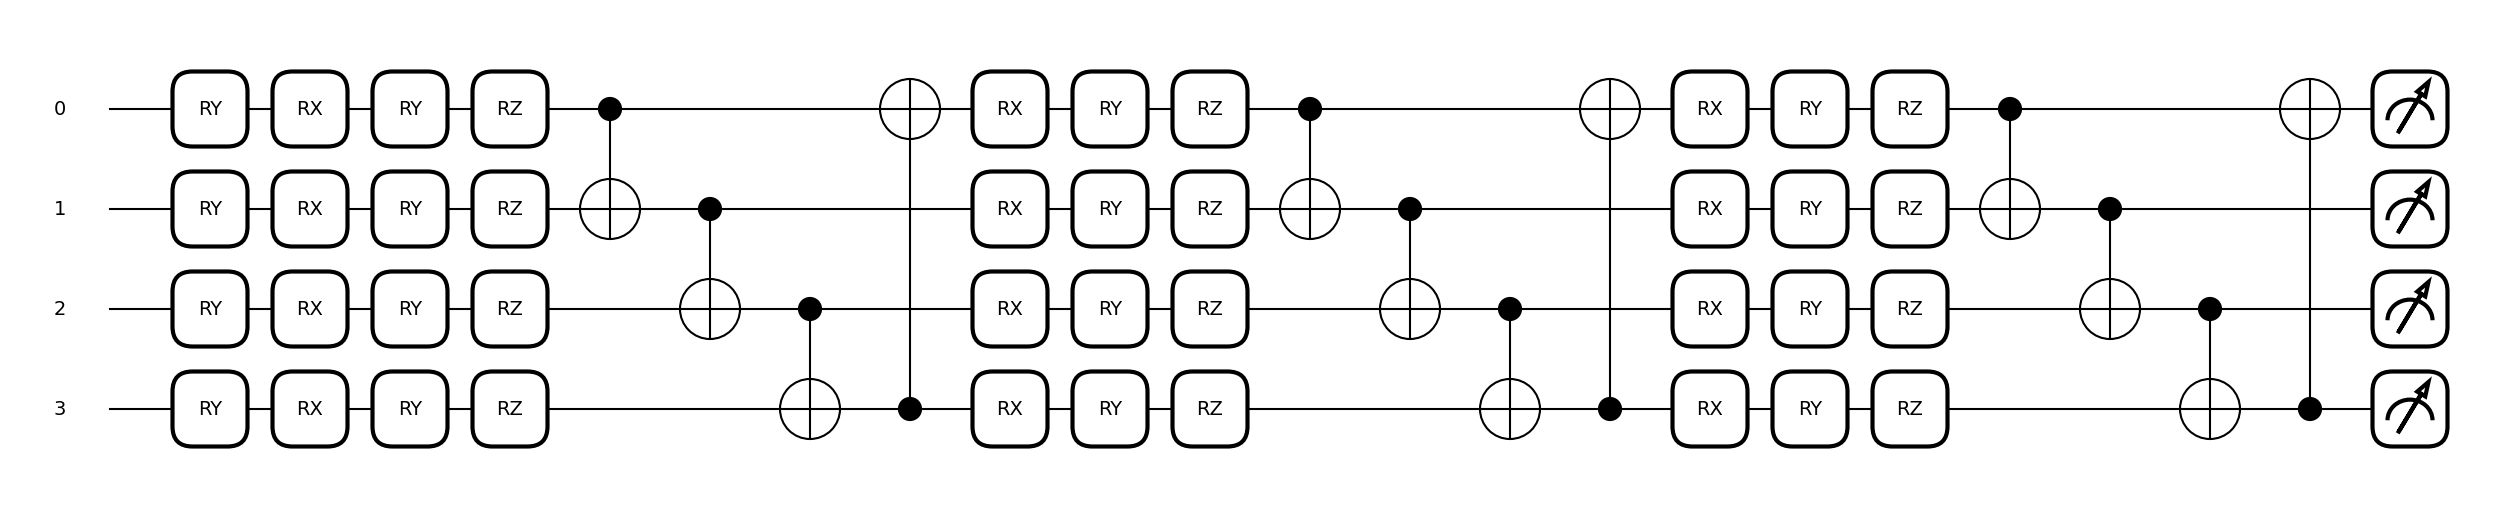

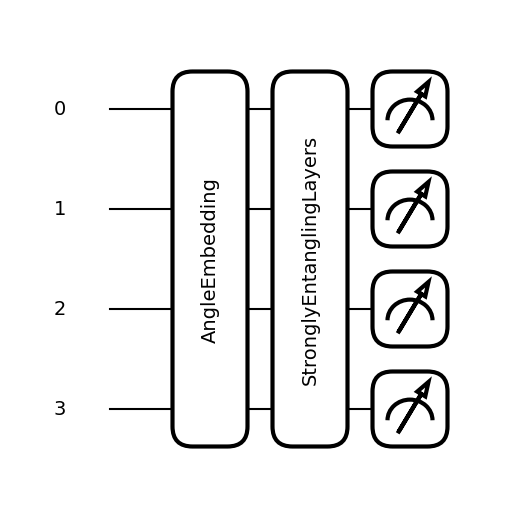

In [3]:
import pennylane as qml
import jax
import jax.numpy as jnp
import optax
from qgan.vqc import simple_circuit, strongly_entangling_circuit
from qgan.utils import draw_circuit


n_qubits, n_layers = 4, 3
dev = qml.device("default.qubit", wires=n_qubits)

simple_qnode = qml.QNode(simple_circuit, dev, interface="jax")
draw_circuit(simple_qnode, n_layers=n_layers, n_qubits=n_qubits)

strongly_qnode = qml.QNode(strongly_entangling_circuit, dev, interface="jax")
draw_circuit(strongly_qnode, n_layers=n_layers, n_qubits=n_qubits)

In [ ]:
import traceback
from qgan.discriminator import Discriminator
from qgan.generator import Generator
from qgan.methods import update_discriminator, update_generator

# ##############################################
# ============ Initial Setup =================
# ##############################################
key = jax.random.PRNGKey(42)

# Instantiate Generator and Discriminator
generator = Generator()
discriminator = Discriminator()

# ##############################################
# ============ Generator Setup =================
# ##############################################
# Initialize random weights for StronglyEntanglingLayers: shape (layers, n_qubits, 3)
key, subkey = jax.random.split(key)
gen_weights = jax.random.normal(subkey, shape=(49, n_layers, n_qubits, 3))

# Generator optimizer setup using Optax
optimizer_G = optax.adam(learning_rate=0.005, b1=0.0, b2=0.9)
opt_state_G = optimizer_G.init(gen_weights)


# ##############################################
# ============ Discriminator Setup =============
# ##############################################
key, key_params, key_dropout = jax.random.split(key, 3)
disc_params = discriminator.init({'params': key_params, 'dropout': key_dropout}, jnp.ones((1, 28, 28, 1)))['params']

# Discriminator optimizer setup using Optax
optimizer_D = optax.adam(learning_rate=0.0002, b1=0.0, b2=0.9)
opt_state_D = optimizer_D.init(disc_params)


# ##############################################
# ============ Training Setup ==================
# ##############################################
# Hyperparameters
lambda_gp = 10.0  #  Penalty coefficient for gradient penalty
lambda_tv = 0.1   #  Coefficient for total variation loss
n_critic = 5      # Number of critic updates per generator update
epochs = 2

# Training Loop
for epoch in range(epochs):
    running_loss_D = 0.0
    running_loss_G = 0.0

    for i, (real_imgs, _) in enumerate(train_ld):
        batch_size = real_imgs.shape[0]
        # Convert to NumPy array
        real_imgs = real_imgs.numpy()  # (batch_size, 1, 28, 28)
        # Reshape into NHWC format
        real_imgs = real_imgs.reshape((batch_size, 28, 28, 1))

        # ---------------------
        #  Train Critic
        # ---------------------
        for entier in range(n_critic):
            key, subkey_noise, subkey_gp = jax.random.split(key, 3)
            z_noise = jax.random.normal(subkey_noise, shape=(batch_size, n_qubits))

            # Update critic parameters (using Optax)
            try:
                disc_params, opt_state_D, loss_D = update_discriminator(
                    strongly_qnode, generator, discriminator, disc_params, gen_weights, 
                    opt_state_D, optimizer_D, z_noise, real_imgs, lambda_gp, subkey_gp)
                
            except Exception as e:
                print("Error during discriminator update:")
                # traceback.print_tb(e.__traceback__)
                raise e
            
        running_loss_D += loss_D
            
        # ---------------------
        #  Train Generator
        # ---------------------
        # Generate new random noise for generator update
        key, subkey_generator, subkey_dropout = jax.random.split(key, 3)
        gen_noise = jax.random.normal(subkey_generator, shape=(batch_size, n_qubits))

        gen_params, opt_state_G, loss_G = update_generator(
            strongly_qnode, generator, discriminator, disc_params, gen_weights, 
            opt_state_G, optimizer_G, gen_noise, subkey_dropout, lambda_tv=lambda_tv)

        running_loss_G += loss_G
        
    # if (epoch + 1) % 40 == 0:
    print(f"Epoch {epoch+1:3d} | Loss D: {running_loss_D:.6f} | Loss G: {running_loss_G:.6f}")

Epoch   1 | Loss D: -6356.831055 | Loss G: 93231.859375
Epoch   2 | Loss D: -18596.804688 | Loss G: 109884.031250
